# SegFormer Ablation Study: Method3との比較

このノートブックは、Method3（U-Net）の代わりに**SegFormer**を使用した場合の性能を評価します。

## SegFormerについて
- **開発元**: NVIDIA Research
- **アーキテクチャ**: Vision Transformer (ViT) ベース
- **特徴**: 軽量かつ高精度なセマンティックセグメンテーション
- **参考**: https://github.com/NVlabs/SegFormer

## 実験設定
- **エポック数**: 300 epochs
- **Early Stopping**: 30 epochs
- **入力解像度**: 512×512
- **モデル**: SegFormer-B2（推奨サイズ）
- **保存先**: `model/ablation_study/segformer_fold{k}_best.pth`
- **評価指標**: Eyelid/Iris/Pupilの Dice係数, 平均 Dice

## 実行順序
1. セル1-2: GPUチェック・基本設定
2. セル3: データセット定義
3. セル4: SegFormerモデル定義
4. セル5: 学習ループ定義
5. セル6: 評価関数定義
7. セル7: 5-Fold CV実行
8. セル8: 結果集計・保存
9. セル9: Method3との比較


## 1. GPUチェック・基本設定


In [1]:
import os
import json
import random
import time
from pathlib import Path
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm.auto import tqdm

# Hugging Face Transformers
from transformers import SegformerForSemanticSegmentation, SegformerConfig
from transformers import SegformerImageProcessor

# ----- GPU確認 -----
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✓ GPUが利用可能")
    print(f"  - GPU: {torch.cuda.get_device_name(0)}")
    print(f"  - CUDA: {torch.version.cuda}")
    print(f"  - PyTorch: {torch.__version__}")
else:
    raise SystemError("GPUが利用できません。CUDA対応GPU/ドライバ/PyTorch(GPU版)を確認してください。")

# ----- 再現性 -----
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed_all(GLOBAL_SEED)
torch.backends.cudnn.benchmark = True

# ----- パス/ハイパーパラメータ -----
IMAGES_DIR     = Path("Images/images")
LABEL_SEG_DIR  = Path("Images/labels_seg")
LABEL_OBB_DIR  = Path("Images/labels_obb")
MODEL_DIR      = Path("model/ablation_study")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_HEIGHT = 512
IMAGE_WIDTH  = 512
BATCH_SIZE   = 8  # SegFormerはメモリ使用量が多いため少し小さく
NUM_EPOCHS   = 300
LEARNING_RATE = 6e-5  # SegFormer推奨学習率（Transformerは低め）
WEIGHT_DECAY  = 1e-4
EARLY_STOP_PATIENCE = 30
NUM_FOLDS = 5
NUM_CLASSES = 6  # 6クラス分類

# データローダー設定
NUM_WORKERS = 0  # Windows対応
PIN_MEMORY = True

# SegFormerモデル設定
# 正しいモデルID（512-512解像度、ハイフン区切り）
SEGFORMER_MODEL_NAME = "nvidia/segformer-b2-finetuned-ade-512-512"  # ImageNet事前学習済み
# 他の選択肢:
# - "nvidia/segformer-b0-finetuned-ade-512-512" (軽量)
# - "nvidia/segformer-b1-finetuned-ade-512-512"
# - "nvidia/segformer-b3-finetuned-ade-512-512" (高精度)
# - "nvidia/segformer-b4-finetuned-ade-512-512"
# - "nvidia/segformer-b5-finetuned-ade-512-512" (最高精度)

# fold indices読み込み
with open('fold_indices.json', 'r') as f:
    fold_indices = json.load(f)

# 画像リスト
df = pd.read_csv('image_metadata.csv')
image_paths = [IMAGES_DIR / row['filename'] for _, row in df.iterrows()]

print(f"\n✓ セットアップ完了")
print(f"  - 画像数: {len(image_paths)}")
print(f"  - モデル保存先: {MODEL_DIR}")
print(f"  - SegFormerモデル: {SEGFORMER_MODEL_NAME}")
print(f"  - エポック数: {NUM_EPOCHS}, Early Stopping: {EARLY_STOP_PATIENCE}")
print(f"  - 学習率: {LEARNING_RATE}, weight_decay: {WEIGHT_DECAY}, バッチ: {BATCH_SIZE}")
print(f"  - Fold数: {NUM_FOLDS}, クラス数: {NUM_CLASSES}")


✓ GPUが利用可能
  - GPU: NVIDIA GeForce RTX 3080 Ti Laptop GPU
  - CUDA: 12.4
  - PyTorch: 2.6.0+cu124

✓ セットアップ完了
  - 画像数: 1992
  - モデル保存先: model\ablation_study
  - SegFormerモデル: nvidia/segformer-b2-finetuned-ade-512-512
  - エポック数: 300, Early Stopping: 30
  - 学習率: 6e-05, weight_decay: 0.0001, バッチ: 8
  - Fold数: 5, クラス数: 6


## 2. データセット定義（crossvalidation.ipynbから再利用）


In [ ]:
# sixcls.pngのBGR色からクラスIDへのマッピング
SIXCLS_BGR_TO_ID = {
    (0, 0, 0): 0,         # background - 黒
    (255, 0, 0): 1,       # conj (lid) - 青(BGR)
    (0, 255, 0): 2,       # iris_vis - 緑
    (0, 0, 255): 3,       # iris_occ - 赤(BGR)
    (0, 255, 255): 4,     # pupil_vis - 黄(BGR)
    (255, 0, 255): 5,     # pupil_occ - マゼンタ(BGR)
}

def _resize_mask(mask, H=IMAGE_HEIGHT, W=IMAGE_WIDTH):
    if mask is None:
        return np.zeros((H, W), dtype=np.uint8)
    return cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)

def convert_sixcls_to_labels(sixcls_img):
    """sixcls.png（BGR形式のカラー画像）をクラスIDラベル（H, W）に変換"""
    H, W = sixcls_img.shape[:2]
    labels = np.zeros((H, W), dtype=np.uint8)
    for bgr_color, class_id in SIXCLS_BGR_TO_ID.items():
        mask = np.all(sixcls_img == bgr_color, axis=2)
        labels[mask] = class_id
    return labels

class EyeSegmentationDataset(Dataset):
    """
    SegFormer用データセット（6クラス分類）
    返すdict:
      - pixel_values: (3,H,W) float tensor (normalized, SegFormer用)
      - labels: (H,W) long tensor (0-5のクラスID)
      - mask_lid, mask_iris, mask_pupil: (H,W) long tensor (評価用)
      - filename: str
    """
    def __init__(self, image_paths, label_seg_dir, label_obb_dir, transform=True):
        self.image_paths = image_paths
        self.label_seg_dir = Path(label_seg_dir)
        self.label_obb_dir = Path(label_obb_dir)
        self.transform = transform
        
        # SegFormer用のImageProcessor（正規化等を自動処理）
        import warnings
        warnings.filterwarnings(
            "ignore",
            message=r"The following named arguments are not valid for `SegformerImageProcessor\\.__init__` and were ignored:.*",
            category=UserWarning,
        )
        self.processor = SegformerImageProcessor.from_pretrained(
            SEGFORMER_MODEL_NAME,
            do_reduce_labels=False,
        )

    def __len__(self): 
        return len(self.image_paths)

    def __getitem__(self, idx):
        p = self.image_paths[idx]
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMAGE_WIDTH, IMAGE_HEIGHT), interpolation=cv2.INTER_LINEAR)

        stem = p.stem
        
        # 6クラスラベル読み込み
        sixcls_path = self.label_seg_dir / f"{stem}_sixcls.png"
        sixcls_img = cv2.imread(str(sixcls_path))
        if sixcls_img is None:
            gt_sixcls = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH), dtype=np.uint8)
        else:
            sixcls_img = cv2.resize(sixcls_img, (IMAGE_WIDTH, IMAGE_HEIGHT), 
                                   interpolation=cv2.INTER_NEAREST)
            gt_sixcls = convert_sixcls_to_labels(sixcls_img)
        
        # 評価用マスク読み込み
        mask_lid   = cv2.imread(str(self.label_seg_dir / f"{stem}_mask_lid.png"),   0)
        mask_iris  = cv2.imread(str(self.label_obb_dir / f"{stem}_mask_iris.png"),  0)
        mask_pupil = cv2.imread(str(self.label_obb_dir / f"{stem}_mask_pupil.png"), 0)
        
        mask_lid   = _resize_mask(mask_lid)
        mask_iris  = _resize_mask(mask_iris)
        mask_pupil = _resize_mask(mask_pupil)

        # SegFormer用の前処理（正規化等）
        # processorはPIL Imageを想定しているので、numpy配列をPILに変換
        from PIL import Image
        img_pil = Image.fromarray(img)
        inputs = self.processor(img_pil, return_tensors="pt")
        
        # テンソルに変換
        pixel_values = inputs['pixel_values'].squeeze(0)  # (3, H, W)
        labels = torch.from_numpy(gt_sixcls).long()

        return {
            'pixel_values': pixel_values,
            'labels': labels,
            'mask_lid': torch.from_numpy(mask_lid).long(),
            'mask_iris': torch.from_numpy(mask_iris).long(),
            'mask_pupil': torch.from_numpy(mask_pupil).long(),
            'filename': p.name
        }

print("✓ データセットクラス定義完了（SegFormer対応）")


✓ データセットクラス定義完了（SegFormer対応）


## 3. SegFormerモデル定義


In [10]:
def create_segformer_model(num_classes=6):
    """SegFormerモデルを作成（6クラス分類用にカスタマイズ）。

    NOTE:
    - `nvidia/segformer-b2-finetuned-ade-512-512` は元々150クラス(ADE20K)用なので、6クラス用に
      `decode_head.classifier` を作り直す必要があります。
    - その結果として「mismatchでclassifierがnewly initialized」という警告が出ますが、
      我々の学習済みチェックポイント（`segformer_fold{k}_best.pth`）を `load_state_dict` で読めば
      最終的には学習済み重みで上書きされるため、**再学習が必要という意味ではありません**。
    """
    # Transformersの警告ログを抑制（毎foldで出て紛らわしいため）
    try:
        from transformers.utils import logging as hf_logging
        hf_logging.set_verbosity_error()
    except Exception:
        pass

    # 事前学習済みモデルをロード（encoder等を初期化）
    model = SegformerForSemanticSegmentation.from_pretrained(
        SEGFORMER_MODEL_NAME,
        num_labels=num_classes,
        ignore_mismatched_sizes=True,
    )

    # デコーダーヘッドを6クラス用に再初期化
    model.config.num_labels = num_classes
    model.decode_head.classifier = nn.Conv2d(
        model.decode_head.classifier.in_channels,
        num_classes,
        kernel_size=1,
    )

    return model

print("✓ SegFormerモデル定義完了")
print(f"  - モデル名: {SEGFORMER_MODEL_NAME}")
print(f"  - クラス数: {NUM_CLASSES}")


✓ SegFormerモデル定義完了
  - モデル名: nvidia/segformer-b2-finetuned-ade-512-512
  - クラス数: 6


## 4. 損失関数・ユーティリティ


In [4]:
def dice_coeff(pred, target, smooth=1e-6):
    """Dice係数を計算"""
    pred_flat = pred.contiguous().view(-1)
    target_flat = target.contiguous().view(-1)
    intersection = (pred_flat * target_flat).sum()
    return (2.0 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

def multi_class_dice_loss(prob, target, num_classes=6, smooth=1e-6):
    """Multi-class Dice Loss"""
    dice_scores = []
    for c in range(num_classes):
        pred_c = prob[:, c, :, :]
        target_c = (target == c).float()
        dice = dice_coeff(pred_c, target_c, smooth)
        dice_scores.append(dice)
    return 1.0 - torch.stack(dice_scores).mean()

class SegFormerLoss(nn.Module):
    """SegFormer用の損失関数（Cross Entropy + Dice Loss）"""
    def __init__(self, use_dice=True, dice_weight=0.5):
        super().__init__()
        self.ce_loss = nn.CrossEntropyLoss(ignore_index=255)
        self.use_dice = use_dice
        self.dice_weight = dice_weight
    
    def forward(self, logits, labels):
        # SegFormerの出力は通常入力の1/4サイズなので、512x512にアップサンプリング
        if logits.shape[-2:] != labels.shape[-2:]:
            logits = F.interpolate(
                logits, 
                size=labels.shape[-2:], 
                mode='bilinear', 
                align_corners=False
            )
        
        # Cross Entropy Loss
        ce = self.ce_loss(logits, labels)
        
        if self.use_dice:
            # Dice Loss
            prob = F.softmax(logits, dim=1)
            dice = multi_class_dice_loss(prob, labels, num_classes=NUM_CLASSES)
            return ce + self.dice_weight * dice
        else:
            return ce

print("✓ 損失関数定義完了")


✓ 損失関数定義完了


In [5]:
def train_epoch(model, loader, criterion, optimizer, scaler, device, show_progress=True):
    """1エポックの学習"""
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    pbar = tqdm(loader, desc="Train", disable=not show_progress)
    for batch in pbar:
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = criterion(outputs.logits, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        num_batches += 1
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / num_batches if num_batches > 0 else 0.0

def validate_epoch(model, loader, criterion, device, show_progress=True):
    """1エポックの検証"""
    model.eval()
    total_loss = 0.0
    num_batches = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Val", disable=not show_progress)
        for batch in pbar:
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            
            with autocast():
                outputs = model(pixel_values=pixel_values, labels=labels)
                loss = criterion(outputs.logits, labels)
            
            total_loss += loss.item()
            num_batches += 1
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / num_batches if num_batches > 0 else 0.0

def run_train_fold(model, loader_tr, loader_va, criterion, optimizer, scaler, 
                   device, fold_idx, progress=None, show_progress=True):
    """1つのFoldの学習を実行（Early Stopping付き + 進捗リアルタイム記録）"""
    best = float('inf')
    patience = 0
    save_path = MODEL_DIR / f"segformer_fold{fold_idx}_best.pth"

    epoch_times = []
    start_all = time.perf_counter()
    stopped_reason = 'unknown'
    
    # 🆕 学習開始を即座に記録（クラッシュ対策）
    if progress is not None:
        mark_in_progress(progress, fold_idx)
    
    for ep in range(1, NUM_EPOCHS + 1):
        start_ep = time.perf_counter()

        tr_loss = train_epoch(model, loader_tr, criterion, optimizer, scaler, device, show_progress=show_progress)
        va_loss = validate_epoch(model, loader_va, criterion, device, show_progress=show_progress)

        ep_time = time.perf_counter() - start_ep
        epoch_times.append(ep_time)
        avg_ep = np.mean(epoch_times)
        remaining = (NUM_EPOCHS - ep) * avg_ep
        
        def fmt(t): 
            m, s = divmod(int(t), 60)
            h, m = divmod(m, 60)
            return f"{h:02d}:{m:02d}:{s:02d}"

        print(f"[SegFormer-F{fold_idx}] Epoch {ep:03d}/{NUM_EPOCHS} | Train {tr_loss:.4f} | Val {va_loss:.4f} | "
              f"Time {fmt(ep_time)} | ETA {fmt(remaining)}")

        if va_loss < best:
            best = va_loss
            patience = 0
            torch.save({
                'model': model.state_dict(),
                'opt': optimizer.state_dict(),
                'scaler': scaler.state_dict(),
                'val_loss': best,
                'epoch': ep,
                'fold': fold_idx,
                'stopped_reason': 'unknown'
            }, save_path)
            print(f"  ✅ Save: {save_path} (best {best:.4f})")
            
            # 🆕 ベストモデル保存時に進捗も更新（クラッシュしても記録が残る）
            if progress is not None:
                update_progress_best(progress, fold_idx, best, ep)
        else:
            patience += 1
            if patience >= EARLY_STOP_PATIENCE:
                print(f"⏹️ Early stop at epoch {ep}")
                stopped_reason = 'early_stop'
                break
        
        if ep == NUM_EPOCHS:
            stopped_reason = 'completed'

    # 最終的な停止理由を記録
    if save_path.exists():
        checkpoint = torch.load(save_path, map_location='cpu')
        checkpoint['stopped_reason'] = stopped_reason
        checkpoint['final_epoch'] = ep
        torch.save(checkpoint, save_path)

    total_time = time.perf_counter() - start_all
    def fmt(t): 
        m, s = divmod(int(t), 60)
        h, m = divmod(m, 60)
        return f"{h:02d}:{m:02d}:{s:02d}"
    
    print(f"[SegFormer-F{fold_idx}] 完了. Total {fmt(total_time)} | Best Val {best:.4f} | 終了理由: {stopped_reason}")
    return best, stopped_reason

print("✓ 学習ループ定義完了")


✓ 学習ループ定義完了


In [ ]:
# ===== 評価（ablation_yolo11_clean_final.ipynb と同一指標） =====
# - 6clsのargmax予測 → eyelid/iris/pupil 二値マスク(0/255)
# - raw / outerarc / fullmax / ransac_whole / ransac_arc を同一の定義で評価
# - per-image（filename, subject_id付き）も保存できるように返す

import cv2
import numpy as np

from skimage.measure import EllipseModel, ransac


def dice_binary_np(pred_bin_255: np.ndarray, gt_bin_255: np.ndarray, smooth=1e-6):
    """0/255の二値マスク同士でDice"""
    p = (pred_bin_255 > 0).astype(np.uint8)
    g = (gt_bin_255 > 0).astype(np.uint8)
    inter = (p & g).sum()
    union = p.sum() + g.sum()
    return float((2 * inter + smooth) / (union + smooth))


def mask_to_edge_max(mask_bin_255: np.ndarray, thickness: int = 3) -> np.ndarray:
    """0/255マスク → 外輪郭（最大輪郭のみ）のエッジ(0/255)"""
    m = (mask_bin_255 > 0).astype(np.uint8)
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    edge = np.zeros_like(mask_bin_255, dtype=np.uint8)
    if not contours:
        return edge
    cnt = max(contours, key=cv2.contourArea)
    cv2.drawContours(edge, [cnt], -1, 255, thickness=thickness)
    return edge


def fit_ellipse_ransac(edge_points_yx, min_samples=5, residual_threshold=2.0, max_trials=100):
    """(y,x)点群にRANSACで楕円フィットし、cv2.ellipse形式で返す（失敗時None）

    skimage の EllipseModel は、点配置が退化している場合などに RuntimeWarning
    （divide by zero / invalid value など）を出すことがあります。
    評価を止めないため、警告は抑制しつつ、NaN/inf 等の破綻パラメータは弾きます。
    """
    if edge_points_yx is None or len(edge_points_yx) < 5:
        return None

    points_xy = edge_points_yx[:, ::-1].astype(np.float64)  # (x,y)

    try:
        import warnings
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=RuntimeWarning, module=r"skimage\\.measure\\.fit")
            warnings.filterwarnings("ignore", category=RuntimeWarning, module=r"skimage\\.measure\\._fit")
            model, inliers = ransac(
                points_xy,
                EllipseModel,
                min_samples=min_samples,
                residual_threshold=residual_threshold,
                max_trials=max_trials,
            )

        if inliers is None or np.sum(inliers) < 5:
            return None

        final_model = EllipseModel()
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=RuntimeWarning)
            ok = final_model.estimate(points_xy[inliers])
        if not ok:
            return None

        xc, yc, a, b, theta = final_model.params
        params = np.array([xc, yc, a, b, theta], dtype=np.float64)
        if not np.all(np.isfinite(params)):
            return None
        if a <= 0 or b <= 0:
            return None

        return ((float(xc), float(yc)), (float(2 * a), float(2 * b)), float(np.degrees(theta)))

    except Exception:
        return None


def binary_to_ellipse_mask(mask_bin_255: np.ndarray, residual_threshold=2.0) -> np.ndarray:
    """whole-mask RANSAC: fullマスク(0/255)→最大輪郭エッジ→RANSAC→楕円マスク(0/255)"""
    H, W = mask_bin_255.shape
    edge = mask_to_edge_max(mask_bin_255, thickness=3)
    pts = np.column_stack(np.where(edge > 0))  # (N,2) (y,x)
    ellipse = fit_ellipse_ransac(pts, residual_threshold=residual_threshold)
    if ellipse is None:
        return np.zeros((H, W), dtype=np.uint8)
    (cx, cy), (w, h), angle = ellipse
    out = np.zeros((H, W), dtype=np.uint8)
    center = (int(round(cx)), int(round(cy)))
    axes = (max(1, int(round(w / 2))), max(1, int(round(h / 2))))
    cv2.ellipse(out, center, axes, float(angle), 0, 360, 255, thickness=-1)
    return out


def ellipse_mask_from_full_max_contour(vis_255: np.ndarray, occ_255: np.ndarray):
    """fullmax: full(vis|occ)の最大外輪郭→cv2.fitEllipse（RANSACなし）"""
    full = (((vis_255 > 0) | (occ_255 > 0)).astype(np.uint8) * 255)
    H, W = full.shape
    m = (full > 0).astype(np.uint8)
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.zeros((H, W), dtype=np.uint8), None
    cnt = max(contours, key=cv2.contourArea)
    pts_xy = cnt.reshape(-1, 2).astype(np.float32)  # (x,y)
    if len(pts_xy) < 5:
        return np.zeros((H, W), dtype=np.uint8), None
    try:
        ellipse = cv2.fitEllipse(pts_xy)
    except Exception:
        return np.zeros((H, W), dtype=np.uint8), None

    (cx, cy), (w, h), angle = ellipse
    out = np.zeros((H, W), dtype=np.uint8)
    center = (int(round(cx)), int(round(cy)))
    axes = (max(1, int(round(w / 2))), max(1, int(round(h / 2))))
    cv2.ellipse(out, center, axes, float(angle), 0, 360, 255, thickness=-1)
    return out, ellipse


def ellipse_mask_from_visible_outer_arc(vis_255: np.ndarray, occ_255: np.ndarray,
                                       boundary_width: int = 7,
                                       vis_near_radius: int = 2,
                                       outer_thickness: int = 2):
    """outerarc: fullの外輪郭から、vis/occ境界を避けた露出弧だけでcv2.fitEllipse（RANSACなし）"""
    H, W = vis_255.shape
    full = ((vis_255 > 0) | (occ_255 > 0)).astype(np.uint8)
    contours, _ = cv2.findContours(full, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.zeros((H, W), dtype=np.uint8), None, None, None, None

    cnt = max(contours, key=cv2.contourArea)
    edge_outer = np.zeros((H, W), dtype=np.uint8)
    cv2.drawContours(edge_outer, [cnt], -1, 255, thickness=outer_thickness)

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    vis = (vis_255 > 0).astype(np.uint8)
    occ = (occ_255 > 0).astype(np.uint8)
    vis_d = cv2.dilate(vis, k, iterations=1)
    occ_d = cv2.dilate(occ, k, iterations=1)
    boundary = ((vis_d & occ_d) > 0).astype(np.uint8)
    boundary_d = cv2.dilate(boundary, k, iterations=max(1, boundary_width))

    allowed_outer = np.where(boundary_d > 0, 0, edge_outer)
    vis_near = cv2.dilate(vis, k, iterations=max(0, vis_near_radius)) if vis_near_radius > 0 else vis
    edge_arc = np.where(vis_near > 0, allowed_outer, 0).astype(np.uint8)

    pts_yx = np.column_stack(np.where(edge_arc > 0))
    if len(pts_yx) < 5:
        return np.zeros((H, W), dtype=np.uint8), None, edge_outer, edge_arc, boundary_d

    pts_xy = pts_yx[:, ::-1].astype(np.float32)
    try:
        ellipse = cv2.fitEllipse(pts_xy)
    except Exception:
        return np.zeros((H, W), dtype=np.uint8), None, edge_outer, edge_arc, boundary_d

    (cx, cy), (w, h), angle = ellipse
    out = np.zeros((H, W), dtype=np.uint8)
    center = (int(round(cx)), int(round(cy)))
    axes = (max(1, int(round(w / 2))), max(1, int(round(h / 2))))
    cv2.ellipse(out, center, axes, float(angle), 0, 360, 255, thickness=-1)
    return out, ellipse, edge_outer, edge_arc, boundary_d


def ransac_ellipse_mask_from_visible_outer_arc(vis_255: np.ndarray, occ_255: np.ndarray,
                                              boundary_width: int = 7,
                                              vis_near_radius: int = 2,
                                              outer_thickness: int = 2,
                                              residual_threshold: float = 2.0):
    """露出弧限定RANSAC: outerarc点群のみをRANSACで楕円化"""
    _mask, _params, _edge_outer, edge_arc, _boundary = ellipse_mask_from_visible_outer_arc(
        vis_255, occ_255,
        boundary_width=boundary_width,
        vis_near_radius=vis_near_radius,
        outer_thickness=outer_thickness,
    )
    if edge_arc is None:
        return np.zeros_like(vis_255)

    pts_yx = np.column_stack(np.where(edge_arc > 0))
    if len(pts_yx) < 5:
        return np.zeros_like(vis_255)

    ellipse = fit_ellipse_ransac(pts_yx, residual_threshold=residual_threshold)
    if ellipse is None:
        return np.zeros_like(vis_255)

    H, W = vis_255.shape
    out = np.zeros((H, W), dtype=np.uint8)
    (cx, cy), (w, h), angle = ellipse
    center = (int(round(cx)), int(round(cy)))
    axes = (max(1, int(round(w / 2))), max(1, int(round(h / 2))))
    cv2.ellipse(out, center, axes, float(angle), 0, 360, 255, thickness=-1)
    return out


def evaluate_segformer_all_modes(model, loader, device, modes=None):
    """SegFormerの6cls出力（argmax）から、指定手法のDiceを計算。

    Returns:
        (out, per_image)
        out: dict[mode] -> {'eyelid','iris','pupil','mean'}  ※画像単位平均
        per_image: dict[mode] -> list[{'filename','subject_id','eyelid','iris','pupil','mean'}]
    """
    model.eval()

    all_modes = ['raw', 'outerarc', 'fullmax', 'ransac_whole', 'ransac_arc']
    if modes is None:
        modes = set(all_modes)
    else:
        modes = set(modes)

    scores = {k: {'eyelid': [], 'iris': [], 'pupil': [], 'mean': []} for k in all_modes}
    per_image = {k: [] for k in all_modes}

    with torch.no_grad():
        desc = 'SegFormer評価（modes=' + ','.join([m for m in all_modes if m in modes]) + ')'
        for batch in tqdm(loader, desc=desc):
            pixel_values = batch['pixel_values'].to(device)
            gt_lid = batch['mask_lid'].cpu().numpy()
            gt_iris = batch['mask_iris'].cpu().numpy()
            gt_pupil = batch['mask_pupil'].cpu().numpy()
            filenames = batch.get('filename', None)

            outputs = model(pixel_values=pixel_values)
            logits = outputs.logits  # (B,6,h,w)

            # 512x512へアップサンプル（YOLO側と同じ最終解像度で評価）
            if logits.shape[-2:] != (IMAGE_HEIGHT, IMAGE_WIDTH):
                logits = F.interpolate(logits, size=(IMAGE_HEIGHT, IMAGE_WIDTH), mode='bilinear', align_corners=False)

            pred_labels = torch.argmax(logits, dim=1).cpu().numpy().astype(np.uint8)  # (B,H,W)

            for b in range(pred_labels.shape[0]):
                pred = pred_labels[b]
                filename = filenames[b] if filenames is not None else str(b)
                subject_id = str(filename).split('-', 1)[0]

                # GT
                gt_l = gt_lid[b]
                gt_i = gt_iris[b]
                gt_p = gt_pupil[b]

                # eyelid（固定）
                lid_pred = (((pred == 1) | (pred == 2) | (pred == 4)).astype(np.uint8) * 255)
                lid_d = dice_binary_np(lid_pred, gt_l)

                # raw masks
                iris_vis = ((pred == 2).astype(np.uint8) * 255)
                iris_occ = ((pred == 3).astype(np.uint8) * 255)
                pupil_vis = ((pred == 4).astype(np.uint8) * 255)
                pupil_occ = ((pred == 5).astype(np.uint8) * 255)

                iris_raw = (((pred == 2) | (pred == 3)).astype(np.uint8) * 255)
                pupil_raw = (((pred == 4) | (pred == 5)).astype(np.uint8) * 255)

                def add(mode, iris_mask_255, pupil_mask_255):
                    i = dice_binary_np(iris_mask_255, gt_i)
                    p = dice_binary_np(pupil_mask_255, gt_p)
                    m = float(np.mean([lid_d, i, p]))
                    scores[mode]['eyelid'].append(lid_d)
                    scores[mode]['iris'].append(i)
                    scores[mode]['pupil'].append(p)
                    scores[mode]['mean'].append(m)
                    per_image[mode].append({
                        'filename': str(filename),
                        'subject_id': str(subject_id),
                        'eyelid': float(lid_d),
                        'iris': float(i),
                        'pupil': float(p),
                        'mean': float(m),
                    })

                if 'raw' in modes:
                    add('raw', iris_raw, pupil_raw)

                if 'outerarc' in modes:
                    iris_outer, _p, *_ = ellipse_mask_from_visible_outer_arc(iris_vis, iris_occ, boundary_width=7, vis_near_radius=2, outer_thickness=2)
                    pupil_outer, _p2, *_ = ellipse_mask_from_visible_outer_arc(pupil_vis, pupil_occ, boundary_width=3, vis_near_radius=1, outer_thickness=2)
                    add('outerarc', iris_outer, pupil_outer)

                if 'fullmax' in modes:
                    iris_fullmax, _ = ellipse_mask_from_full_max_contour(iris_vis, iris_occ)
                    pupil_fullmax, _ = ellipse_mask_from_full_max_contour(pupil_vis, pupil_occ)
                    add('fullmax', iris_fullmax, pupil_fullmax)

                if 'ransac_whole' in modes:
                    iris_r = binary_to_ellipse_mask(iris_raw)
                    pupil_r = binary_to_ellipse_mask(pupil_raw)
                    add('ransac_whole', iris_r, pupil_r)

                if 'ransac_arc' in modes:
                    iris_ra = ransac_ellipse_mask_from_visible_outer_arc(iris_vis, iris_occ, boundary_width=7, vis_near_radius=2, outer_thickness=2)
                    pupil_ra = ransac_ellipse_mask_from_visible_outer_arc(pupil_vis, pupil_occ, boundary_width=3, vis_near_radius=1, outer_thickness=2)
                    add('ransac_arc', iris_ra, pupil_ra)

    out = {}
    for mode in all_modes:
        out[mode] = {
            'eyelid': float(np.mean(scores[mode]['eyelid'])) if len(scores[mode]['eyelid']) else 0.0,
            'iris': float(np.mean(scores[mode]['iris'])) if len(scores[mode]['iris']) else 0.0,
            'pupil': float(np.mean(scores[mode]['pupil'])) if len(scores[mode]['pupil']) else 0.0,
            'mean': float(np.mean(scores[mode]['mean'])) if len(scores[mode]['mean']) else 0.0,
        }

    return out, per_image


print("✓ 評価関数を更新しました（ablation_yolo11_clean_final.ipynb と同一指標）")


✓ 評価関数を更新しました（ablation_yolo11_clean_final.ipynb と同一指標）


### 進捗確認・リセット（オプション）

進捗状態を確認したり、最初からやり直す場合に使用します。


In [77]:
# ===== 進捗確認 =====
# PROGRESS_FILEの定義（セル16で定義されているが、ここでも定義）
PROGRESS_FILE = Path("cache/ablation_progress.json")

def load_progress():
    """進捗状態を読み込み"""
    if PROGRESS_FILE.exists():
        with open(PROGRESS_FILE, 'r') as f:
            return json.load(f)
    return {
        "completed": {},      # 完了したFold
        "in_progress": {},    # 実行中のFold（途中で中断された）
        "started_at": None, 
        "last_update": None
    }

print("=" * 80)
print("📊 進捗状態の確認")
print("=" * 80)

if PROGRESS_FILE.exists():
    progress_check = load_progress()
    
    print(f"\n📅 実行情報:")
    print(f"   開始時刻: {progress_check.get('started_at', 'N/A')}")
    print(f"   最終更新: {progress_check.get('last_update', 'N/A')}")
    
    completed_count = len(progress_check.get('completed', {}))
    in_progress_count = len(progress_check.get('in_progress', {}))
    
    print(f"\n📈 進捗状況:")
    print(f"   総Fold数: {NUM_FOLDS}")
    print(f"   完了Fold: {completed_count}")
    print(f"   実行中: {in_progress_count}（途中で中断されたFold）")
    print(f"   完了率: {completed_count / NUM_FOLDS * 100:.1f}%")
    
    # 完了済みFoldの詳細
    if completed_count > 0:
        print(f"\n✅ 完了済みFold:")
        for key, info in progress_check.get('completed', {}).items():
            fold_num = key.replace('fold_', '')
            stopped_reason = info.get('stopped_reason', 'unknown')
            status_emoji = "🏁" if stopped_reason == 'completed' else "⏹️" if stopped_reason == 'early_stop' else "✅"
            print(f"   {status_emoji} Fold {fold_num}: Epoch {info['epoch']}, Loss {info['best_val_loss']:.4f}, {stopped_reason}")
    
    # 実行中Foldの詳細
    if in_progress_count > 0:
        print(f"\n🔄 実行中のFold（未完了）:")
        for key, info in progress_check.get('in_progress', {}).items():
            fold_num = key.replace('fold_', '')
            current_epoch = info.get('current_epoch', 0)
            current_loss = info.get('current_best_loss', float('inf'))
            started = info.get('started_at', 'N/A')
            last_update = info.get('last_update', 'N/A')
            print(f"   🔄 Fold {fold_num}:")
            print(f"      開始: {started}")
            print(f"      最終更新: {last_update}")
            print(f"      進捗: Epoch {current_epoch}/{NUM_EPOCHS} | Best Loss: {current_loss:.4f}")
            print(f"      → 次回実行時に続きから再開されます")
else:
    print("\n✅ 進捗ファイルが存在しません（未実行または完全リセット済み）")
    print("   次回実行時は最初から開始されます。")

# ===== 進捗リセット（最初からやり直す場合） =====
RESET_PROGRESS = False  # Trueに変更すると進捗をリセット

if RESET_PROGRESS:
    if PROGRESS_FILE.exists():
        PROGRESS_FILE.unlink()
        print("\n🔄 進捗をリセットしました")
    else:
        print("\n✅ 進捗ファイルが存在しないため、リセット不要です")
else:
    print("\n💡 進捗をリセットする場合は、RESET_PROGRESS = True に変更してください")


📊 進捗状態の確認

✅ 進捗ファイルが存在しません（未実行または完全リセット済み）
   次回実行時は最初から開始されます。

💡 進捗をリセットする場合は、RESET_PROGRESS = True に変更してください


## 6. Resume機能（進捗管理）


In [7]:
# ===== Resume機能：進捗管理 =====
PROGRESS_FILE = Path("cache/ablation_progress_segformer.json")

def load_progress():
    """進捗状態を読み込み"""
    if PROGRESS_FILE.exists():
        with open(PROGRESS_FILE, 'r') as f:
            return json.load(f)
    return {
        "completed": {},      # 完了したFold
        "in_progress": {},    # 実行中のFold（途中で中断された）
        "started_at": None, 
        "last_update": None
    }

def save_progress(progress):
    """進捗状態を保存"""
    progress["last_update"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    PROGRESS_FILE.parent.mkdir(parents=True, exist_ok=True)
    with open(PROGRESS_FILE, 'w') as f:
        json.dump(progress, f, indent=2)

def verify_model_file(fold_idx):
    """モデルファイルが正常に存在するか検証"""
    model_path = MODEL_DIR / f"segformer_fold{fold_idx}_best.pth"
    
    if not model_path.exists():
        return False, "ファイルが存在しません"
    
    try:
        checkpoint = torch.load(model_path, map_location='cpu')
        
        if 'model' not in checkpoint:
            return False, "モデルstate_dictが見つかりません"
        
        if 'epoch' not in checkpoint or 'val_loss' not in checkpoint:
            return False, "チェックポイント情報が不完全です"
        
        if model_path.stat().st_size < 1000000:  # 1MB未満は異常
            return False, f"ファイルサイズが異常に小さい ({model_path.stat().st_size} bytes)"
        
        # 終了理由をチェック
        stopped_reason = checkpoint.get('stopped_reason', 'unknown')
        if stopped_reason == 'unknown':
            final_epoch = checkpoint.get('final_epoch', checkpoint.get('epoch', 0))
            if final_epoch < NUM_EPOCHS:
                return False, f"途中で中断された可能性 (epoch={final_epoch}, reason=unknown)"
        
        return True, checkpoint
    
    except Exception as e:
        return False, f"ファイル読み込みエラー: {str(e)}"

def is_completed(progress, fold_idx):
    """指定されたFoldが完了済みか確認（モデルファイルも検証）"""
    key = f"fold_{fold_idx}"
    
    # in_progressに存在する場合は未完了（途中で中断された）
    if key in progress.get("in_progress", {}):
        print(f"    🔄 Fold {fold_idx}: 前回途中で中断されました")
        in_progress_info = progress["in_progress"][key]
        current_epoch = in_progress_info.get('current_epoch', 0)
        current_loss = in_progress_info.get('current_best_loss', float('inf'))
        print(f"       前回進捗: Epoch {current_epoch} | Best Loss: {current_loss:.4f}")
        print(f"       → 最初から再学習します")
        
        # in_progressから削除（再学習のため）
        del progress["in_progress"][key]
        save_progress(progress)
        return False
    
    # 進捗JSONのcompletedに記録されているか
    if key not in progress.get("completed", {}):
        return False
    
    # モデルファイルを検証
    is_valid, info = verify_model_file(fold_idx)
    if not is_valid:
        print(f"    ⚠️ Fold {fold_idx}: モデルファイルに問題があります")
        print(f"       {info}")
        print(f"       → 進捗から削除して再学習します")
        
        # 進捗から削除
        if key in progress["completed"]:
            del progress["completed"][key]
        save_progress(progress)
        return False
    
    return True

def mark_in_progress(progress, fold_idx):
    """学習開始を記録（in_progress状態）"""
    key = f"fold_{fold_idx}"
    
    if "in_progress" not in progress:
        progress["in_progress"] = {}
    
    progress["in_progress"][key] = {
        "started_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "current_epoch": 0,
        "current_best_loss": float('inf')
    }
    save_progress(progress)

def update_progress_best(progress, fold_idx, best_val_loss, epoch):
    """ベストモデル更新時に進捗を更新"""
    key = f"fold_{fold_idx}"
    
    if "in_progress" not in progress:
        progress["in_progress"] = {}
    
    if key in progress["in_progress"]:
        progress["in_progress"][key]["current_epoch"] = int(epoch)
        progress["in_progress"][key]["current_best_loss"] = float(best_val_loss)
        progress["in_progress"][key]["last_update"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        save_progress(progress)

def mark_completed(progress, fold_idx, best_val_loss, epoch, stopped_reason='completed'):
    """Foldを完了としてマーク（in_progressから削除してcompletedに移動）"""
    key = f"fold_{fold_idx}"
    
    # in_progressから削除
    if "in_progress" in progress and key in progress["in_progress"]:
        del progress["in_progress"][key]
    
    # completedに追加
    progress["completed"][key] = {
        "best_val_loss": float(best_val_loss),
        "epoch": int(epoch),
        "stopped_reason": stopped_reason,
        "completed_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }
    save_progress(progress)

print("✓ Resume機能定義完了")


✓ Resume機能定義完了


In [8]:
# ===== 進捗管理の初期化 =====
progress = load_progress()

# 開始時刻を記録（初回のみ）
if progress.get('started_at') is None:
    progress['started_at'] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    save_progress(progress)

print("=" * 80)
print("🚀 SegFormer 5-Fold Cross-Validation 開始")
if len(progress.get('completed', {})) > 0 or len(progress.get('in_progress', {})) > 0:
    print("🔄 Resume: 前回の続きから実行")
    completed_count = len(progress.get('completed', {}))
    in_progress_count = len(progress.get('in_progress', {}))
    print(f"   完了済み: {completed_count} / {NUM_FOLDS} Folds")
    if in_progress_count > 0:
        print(f"   実行中: {in_progress_count} / {NUM_FOLDS} Folds")
    print(f"   開始時刻: {progress.get('started_at', 'N/A')}")
    print(f"   最終更新: {progress.get('last_update', 'N/A')}")
print("=" * 80)

# ===== 評価結果CSV（ablation_yolo11_clean_final.ipynb と同形式） =====
results_dir = Path('results')
results_dir.mkdir(exist_ok=True)

timestamp_nonransac = datetime.now().strftime('%Y%m%d_%H%M%S')
rows_nonransac = { 'raw': [], 'outerarc': [], 'fullmax': [] }

fold_results = []

for fold_idx in range(NUM_FOLDS):
    print(f"\n{'='*80}")
    print(f"Fold {fold_idx} / {NUM_FOLDS - 1}")
    print(f"{'='*80}")
    
    # Train/Val分割
    train_indices = fold_indices[str(fold_idx)]['train']
    val_indices = fold_indices[str(fold_idx)]['val']
    
    train_paths = [image_paths[i] for i in train_indices]
    val_paths = [image_paths[i] for i in val_indices]
    
    train_ds = EyeSegmentationDataset(train_paths, LABEL_SEG_DIR, LABEL_OBB_DIR)
    val_ds = EyeSegmentationDataset(val_paths, LABEL_SEG_DIR, LABEL_OBB_DIR)
    
    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )
    
    print(f"  Train: {len(train_ds)}, Val: {len(val_ds)}")
    
    # モデル作成
    model = create_segformer_model(num_classes=NUM_CLASSES).to(device)
    criterion = SegFormerLoss(use_dice=True, dice_weight=0.5)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scaler = GradScaler()
    
    # 完了済みFoldのスキップ
    if is_completed(progress, fold_idx):
        print(f"  ⏹️ Fold {fold_idx}: 完了済みスキップ")
        completed_info = progress['completed'][f'fold_{fold_idx}']
        print(f"     Best Val Loss: {completed_info['best_val_loss']:.4f} (Epoch {completed_info['epoch']})")
        print(f"     終了理由: {completed_info['stopped_reason']}")
        print(f"     → 評価のみ実行")
        
        # モデルをロードして評価
        model = create_segformer_model(num_classes=NUM_CLASSES).to(device)
        checkpoint = torch.load(MODEL_DIR / f"segformer_fold{fold_idx}_best.pth", map_location=device)
        model.load_state_dict(checkpoint['model'])
        
        # 評価実行
        print(f"\n  📊 評価中...")
        out, per_image = evaluate_segformer_all_modes(model, val_loader, device, modes=['raw','outerarc','fullmax'])
        eval_results = out['raw']  # 後方互換（表示用）

        # fold平均（非RANSAC3手法）を蓄積
        for mode in ['raw','outerarc','fullmax']:
            r = dict(out[mode])
            r['fold'] = fold_idx
            rows_nonransac[mode].append(r)

        # per-image CSVを追記保存
        for mode in ['raw','outerarc','fullmax']:
            df_img = pd.DataFrame(per_image[mode])
            df_img['fold'] = fold_idx
            out_img_path = results_dir / f"segformer_eval_perimage_{mode}_{timestamp_nonransac}.csv"
            header = not out_img_path.exists()
            df_img.to_csv(out_img_path, index=False, mode='a', header=header)

        fold_results.append({
            'fold': fold_idx,
            'train_size': len(train_ds),
            'val_size': len(val_ds),
            'best_val_loss': completed_info['best_val_loss'],
            'stopped_reason': completed_info['stopped_reason'],
            **eval_results,
            # 参考：非RANSACの結果も入れておく（集計は後段でCSVから行う）
            'outerarc_mean': out['outerarc']['mean'],
            'fullmax_mean': out['fullmax']['mean'],
        })

        print(f"  ✅ Fold {fold_idx} 評価完了")
        print(f"     [raw]     Mean Dice: {out['raw']['mean']:.4f}")
        print(f"     [outerarc] Mean Dice: {out['outerarc']['mean']:.4f}")
        print(f"     [fullmax]  Mean Dice: {out['fullmax']['mean']:.4f}")
        
        # メモリクリア
        del model
        torch.cuda.empty_cache()
        continue
    
    # 学習実行（progressを渡す）
    best_val_loss, stopped_reason = run_train_fold(
        model, train_loader, val_loader, criterion, optimizer, scaler,
        device, fold_idx, progress=progress, show_progress=True
    )
    
    # モデルチェックポイントから最終エポックを取得
    checkpoint_path = MODEL_DIR / f"segformer_fold{fold_idx}_best.pth"
    if checkpoint_path.exists():
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        final_epoch = checkpoint.get('epoch', NUM_EPOCHS)
    else:
        final_epoch = NUM_EPOCHS
    
    # 学習完了を記録
    mark_completed(progress, fold_idx, best_val_loss, final_epoch, stopped_reason)
    
    # 評価実行
    print(f"\n  📊 評価中...")
    out, per_image = evaluate_segformer_all_modes(model, val_loader, device, modes=['raw','outerarc','fullmax'])
    eval_results = out['raw']  # 後方互換（表示用）

    # fold平均（非RANSAC3手法）を蓄積
    for mode in ['raw','outerarc','fullmax']:
        r = dict(out[mode])
        r['fold'] = fold_idx
        rows_nonransac[mode].append(r)

    # per-image CSVを追記保存
    for mode in ['raw','outerarc','fullmax']:
        df_img = pd.DataFrame(per_image[mode])
        df_img['fold'] = fold_idx
        out_img_path = results_dir / f"segformer_eval_perimage_{mode}_{timestamp_nonransac}.csv"
        header = not out_img_path.exists()
        df_img.to_csv(out_img_path, index=False, mode='a', header=header)

    fold_results.append({
        'fold': fold_idx,
        'train_size': len(train_ds),
        'val_size': len(val_ds),
        'best_val_loss': best_val_loss,
        'stopped_reason': stopped_reason,
        **eval_results,
        'outerarc_mean': out['outerarc']['mean'],
        'fullmax_mean': out['fullmax']['mean'],
    })

    print(f"  ✅ Fold {fold_idx} 完了")
    print(f"     [raw]     Mean Dice: {out['raw']['mean']:.4f}")
    print(f"     [outerarc] Mean Dice: {out['outerarc']['mean']:.4f}")
    print(f"     [fullmax]  Mean Dice: {out['fullmax']['mean']:.4f}")
    
    # メモリクリア
    del model, criterion, optimizer, scaler
    torch.cuda.empty_cache()

print("\n" + "=" * 80)
print("✅ 全Fold学習完了")
print("=" * 80)

# ===== 非RANSAC評価（raw / outerarc / fullmax）のCSV保存 =====
paths = {}
for mode in ['raw','outerarc','fullmax']:
    dfm = pd.DataFrame(rows_nonransac[mode])
    out_path = results_dir / f"segformer_eval_{mode}_{timestamp_nonransac}.csv"
    dfm.to_csv(out_path, index=False)
    paths[mode] = out_path
    print(f"✅ 保存: {out_path}")

# 平均比較表（非RANSAC）
summary_rows = []
for mode in ['raw','outerarc','fullmax']:
    dfm = pd.DataFrame(rows_nonransac[mode])
    summary_rows.append({
        'method': mode,
        'eyelid_mean': float(dfm['eyelid'].mean()),
        'iris_mean': float(dfm['iris'].mean()),
        'pupil_mean': float(dfm['pupil'].mean()),
        'overall_mean': float(dfm['mean'].mean()),
    })

df_sum = pd.DataFrame(summary_rows)
comp_path = results_dir / f"segformer_comparison_nonransac_{timestamp_nonransac}.csv"
df_sum.to_csv(comp_path, index=False)
print(f"\n✅ 平均比較表を保存: {comp_path}")
print(df_sum)


🚀 SegFormer 5-Fold Cross-Validation 開始
🔄 Resume: 前回の続きから実行
   完了済み: 5 / 5 Folds
   開始時刻: 2025-12-13 07:38:27
   最終更新: 2025-12-16 17:54:30

Fold 0 / 4


c:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\venv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


  Train: 1593, Val: 399


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b2-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([150, 768, 1, 1]) in the checkpoint and torch.Size([6, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([6]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\CorneAI\AppData\Local\Temp\ipykernel_60480\1171593232.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


  ⏹️ Fold 0: 完了済みスキップ
     Best Val Loss: 0.1160 (Epoch 18)
     終了理由: early_stop
     → 評価のみ実行


...

  ⏹️ Fold 4: 完了済みスキップ
     Best Val Loss: 0.1177 (Epoch 22)
     終了理由: early_stop
     → 評価のみ実行


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b2-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([150, 768, 1, 1]) in the checkpoint and torch.Size([6, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([6]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



  📊 評価中...


SegFormer評価（modes=raw,outerarc,fullmax):   0%|          | 0/50 [00:00<?, ?it/s]

  ✅ Fold 4 評価完了
     [raw]     Mean Dice: 0.9415
     [outerarc] Mean Dice: 0.9583
     [fullmax]  Mean Dice: 0.9646

✅ 全Fold学習完了
✅ 保存: results\segformer_eval_raw_20260101_005953.csv
✅ 保存: results\segformer_eval_outerarc_20260101_005953.csv
✅ 保存: results\segformer_eval_fullmax_20260101_005953.csv

✅ 平均比較表を保存: results\segformer_comparison_nonransac_20260101_005953.csv
     method  eyelid_mean  iris_mean  pupil_mean  overall_mean
0       raw     0.985567   0.896914    0.932669      0.938383
1  outerarc     0.985567   0.941616    0.928318      0.951834
2   fullmax     0.985567   0.964456    0.932080      0.960701


In [12]:
# ===== RANSAC評価（2手法：whole / arc）を別セルで実行（重いので任意） =====
# 出力:
# - results/segformer_eval_ransac_whole_*.csv
# - results/segformer_eval_ransac_arc_*.csv
# - results/segformer_eval_perimage_ransac_whole_*.csv
# - results/segformer_eval_perimage_ransac_arc_*.csv
# - results/segformer_comparison_ransac_*.csv

from pathlib import Path
from datetime import datetime
import pandas as pd

results_dir = Path('results')
results_dir.mkdir(exist_ok=True)

timestamp_ransac = datetime.now().strftime('%Y%m%d_%H%M%S')
rows_ransac = { 'ransac_whole': [], 'ransac_arc': [] }

print('\n' + '='*80)
print('SegFormer RANSAC評価（2手法）開始')
print('='*80)

for fold_idx in range(NUM_FOLDS):
    print(f"\nFold {fold_idx} 評価中...")

    model_path = MODEL_DIR / f"segformer_fold{fold_idx}_best.pth"
    if not model_path.exists():
        print(f"  ⚠️ モデルが見つかりません: {model_path}")
        continue

    # val loader
    val_indices = fold_indices[str(fold_idx)]['val']
    val_paths = [image_paths[i] for i in val_indices]
    val_ds = EyeSegmentationDataset(val_paths, LABEL_SEG_DIR, LABEL_OBB_DIR)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

    model = create_segformer_model(num_classes=NUM_CLASSES).to(device)
    ckpt = torch.load(model_path, map_location=device)
    model.load_state_dict(ckpt['model'])

    out, per_image = evaluate_segformer_all_modes(model, val_loader, device, modes=['ransac_whole','ransac_arc'])

    for mode in ['ransac_whole','ransac_arc']:
        r = dict(out[mode])
        r['fold'] = fold_idx
        rows_ransac[mode].append(r)

        df_img = pd.DataFrame(per_image[mode])
        df_img['fold'] = fold_idx
        out_img_path = results_dir / f"segformer_eval_perimage_{mode}_{timestamp_ransac}.csv"
        header = not out_img_path.exists()
        df_img.to_csv(out_img_path, index=False, mode='a', header=header)

    print('  ✅ Fold結果（mean Dice）:', {k: f"{out[k]['mean']:.4f}" for k in ['ransac_whole','ransac_arc']})

print('\n' + '='*80)
print('✅ SegFormer RANSAC評価 完了')
print('='*80)

# CSV保存（fold平均）
for mode in ['ransac_whole','ransac_arc']:
    dfm = pd.DataFrame(rows_ransac[mode])
    out_path = results_dir / f"segformer_eval_{mode}_{timestamp_ransac}.csv"
    dfm.to_csv(out_path, index=False)
    print(f"✅ 保存: {out_path}")

# 平均比較表（RANSAC）
summary_rows = []
for mode in ['ransac_whole','ransac_arc']:
    dfm = pd.DataFrame(rows_ransac[mode])
    summary_rows.append({
        'method': mode,
        'eyelid_mean': float(dfm['eyelid'].mean()),
        'iris_mean': float(dfm['iris'].mean()),
        'pupil_mean': float(dfm['pupil'].mean()),
        'overall_mean': float(dfm['mean'].mean()),
    })

df_sum = pd.DataFrame(summary_rows)
comp_path = results_dir / f"segformer_comparison_ransac_{timestamp_ransac}.csv"
df_sum.to_csv(comp_path, index=False)
print(f"\n✅ 平均比較表を保存: {comp_path}")
print(df_sum)




SegFormer RANSAC評価（2手法）開始

Fold 0 評価中...


SegFormer評価（modes=ransac_whole,ransac_arc):   0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\venv\Lib\site-packages\skimage\measure\fit.py:530: RuntimeWarning: divide by zero encountered in scalar divide
  phi = 0.5 * np.arctan((2.0 * b) / (a - c))


  ✅ Fold結果（mean Dice）: {'ransac_whole': '0.9625', 'ransac_arc': '0.9530'}

Fold 1 評価中...


c:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\venv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


...

c:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\venv\Lib\site-packages\skimage\measure\fit.py:530: RuntimeWarning: divide by zero encountered in scalar divide
  phi = 0.5 * np.arctan((2.0 * b) / (a - c))
c:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\venv\Lib\site-packages\skimage\measure\fit.py:525: RuntimeWarning: divide by zero encountered in scalar divide
  width = np.sqrt(2 * numerator / denominator1)
c:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\venv\Lib\site-packages\skimage\measure\fit.py:525: RuntimeWarning: invalid value encountered in sqrt
  width = np.sqrt(2 * numerator / denominator1)


  ✅ Fold結果（mean Dice）: {'ransac_whole': '0.9561', 'ransac_arc': '0.9428'}

Fold 4 評価中...


c:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\venv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


SegFormer評価（modes=ransac_whole,ransac_arc):   0%|          | 0/50 [00:00<?, ?it/s]

  ✅ Fold結果（mean Dice）: {'ransac_whole': '0.9626', 'ransac_arc': '0.9542'}

✅ SegFormer RANSAC評価 完了
✅ 保存: results\segformer_eval_ransac_whole_20260101_170840.csv
✅ 保存: results\segformer_eval_ransac_arc_20260101_170840.csv

✅ 平均比較表を保存: results\segformer_comparison_ransac_20260101_170840.csv
         method  eyelid_mean  iris_mean  pupil_mean  overall_mean
0  ransac_whole     0.985567   0.963110    0.927774      0.958817
1    ransac_arc     0.985567   0.929714    0.925957      0.947079


In [14]:
# ===== 結果集計（CSVから読む：SegFormer / 非RANSAC / RANSAC） =====
# ablation_yolo11_clean_final.ipynb と同じ考え方で、最新のCSVから集計します。

from pathlib import Path
import pandas as pd
import numpy as np

results_dir = Path('results')

def latest_csv(glob_pat: str):
    files = sorted(results_dir.glob(glob_pat), key=lambda p: p.stat().st_mtime, reverse=True)
    return files[0] if files else None

def print_block(title: str):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

# fold平均（参考）
print_block("【SegFormer: fold平均（参考）】")
all_modes = ['raw','outerarc','fullmax','ransac_whole','ransac_arc']
rows = []
for mode in all_modes:
    p = latest_csv(f"segformer_eval_{mode}_*.csv")
    if p is None:
        continue
    df = pd.read_csv(p)
    print(f"\n[{mode}] {p.name}")
    print(f"  CSVパス: {p.resolve()}")
    rows.append({
        'method': mode,
        'eyelid_mean': float(df['eyelid'].mean()),
        'iris_mean': float(df['iris'].mean()),
        'pupil_mean': float(df['pupil'].mean()),
        'overall_mean': float(df['mean'].mean()),
    })

if rows:
    df_sum = pd.DataFrame(rows).sort_values('overall_mean', ascending=False)
    print("\n--- 平均（fold平均） ---")
    print(df_sum.to_string(index=False))
else:
    print("⚠️ segformer_eval_*.csv が見つかりません。先に評価を実行してください。")

# 被験者クラスタ統計（推奨）
print_block("【SegFormer: 被験者クラスタ統計（推奨）】")

per_paths = {m: latest_csv(f"segformer_eval_perimage_{m}_*.csv") for m in all_modes}
for m,p in per_paths.items():
    if p is None:
        continue
    print(f"  ✅ {m}: {p.resolve()}")

if per_paths.get('raw') is None or per_paths.get('outerarc') is None or per_paths.get('fullmax') is None:
    print("⚠️ per-image CSV（raw/outerarc/fullmax）が不足しています。非RANSAC評価セルを実行してください。")
else:
    def load_subj_mean(path: Path):
        df = pd.read_csv(path)
        if 'subject_id' not in df.columns:
            df['subject_id'] = df['filename'].astype(str).str.split('-', n=1).str[0]
        return df.groupby('subject_id')[['mean','eyelid','iris','pupil']].mean()

    subj = {m: load_subj_mean(p) for m,p in per_paths.items() if p is not None}

    # ranking（mean）
    rank = pd.DataFrame([
        {'method': m, 'subject_mean_dice': float(subj[m]['mean'].mean()), 'n_subjects': int(subj[m].shape[0])}
        for m in subj.keys()
    ]).sort_values('subject_mean_dice', ascending=False)

    print("\n--- 被験者平均Dice（mean）のランキング ---")
    print(rank.to_string(index=False))

    # direct comparison（full vs exposed）
    def holm_adjust(pvals: dict):
        items = sorted(pvals.items(), key=lambda kv: kv[1])
        m = len(items)
        out = {}
        prev = 0.0
        for j, (name, p) in enumerate(items, start=1):
            adj = min(1.0, (m - j + 1) * p)
            adj = max(prev, adj)
            prev = adj
            out[name] = adj
        return out

    def paired_perm_p(diff: np.ndarray, n_perm=20000, seed=0):
        rng = np.random.default_rng(seed)
        obs = float(diff.mean())
        signs = rng.choice(np.array([-1.0, 1.0]), size=(n_perm, diff.size), replace=True)
        perm = (signs * diff[None, :]).mean(axis=1)
        p = float((np.abs(perm) >= abs(obs)).mean())
        return obs, p

    def paired_boot_ci(diff: np.ndarray, n_boot=20000, seed=1):
        rng = np.random.default_rng(seed)
        n = diff.size
        idx = rng.integers(0, n, size=(n_boot, n))
        boot = diff[idx].mean(axis=1)
        lo, hi = np.quantile(boot, [0.025, 0.975])
        return float(lo), float(hi)

    print("\n--- 直接比較（mean Dice）：full vs 露出（被験者クラスタ / 置換検定 + Holm） ---")
    pair_specs = [('fullmax','outerarc')]
    if 'ransac_whole' in subj and 'ransac_arc' in subj:
        pair_specs.append(('ransac_whole','ransac_arc'))

    rows_pair = []
    pvals = {}
    for a,b in pair_specs:
        common = subj[a].index.intersection(subj[b].index)
        diff = (subj[a].loc[common,'mean'].to_numpy() - subj[b].loc[common,'mean'].to_numpy()).astype(float)
        obs, p = paired_perm_p(diff, seed=10)
        lo, hi = paired_boot_ci(diff, seed=11)
        win = float((diff > 0).mean())
        key = f"{a}-{b}"
        pvals[key] = p
        rows_pair.append({
            'compare': f"{a} - {b}",
            'n_subjects': int(len(common)),
            'mean_diff': float(obs),
            'ci95_low': float(lo),
            'ci95_high': float(hi),
            'win_rate': float(win),
            'p_perm': float(p),
        })

    if rows_pair:
        ph = holm_adjust(pvals)
        for r in rows_pair:
            k = r['compare'].replace(' - ','-')
            r['p_holm'] = float(ph.get(k, np.nan))
        df_pair = pd.DataFrame(rows_pair).sort_values('p_perm')
        print(df_pair.to_string(index=False))

print_block("結果集計完了")



【SegFormer: fold平均（参考）】

[raw] segformer_eval_raw_20260101_005953.csv
  CSVパス: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\results\segformer_eval_raw_20260101_005953.csv

[outerarc] segformer_eval_outerarc_20260101_005953.csv
  CSVパス: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\results\segformer_eval_outerarc_20260101_005953.csv

[fullmax] segformer_eval_fullmax_20260101_005953.csv
  CSVパス: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\results\segformer_eval_fullmax_20260101_005953.csv

[ransac_whole] segformer_eval_ransac_whole_20260101_170840.csv
  CSVパス: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\results\segformer_eval_ransac_whole_20260101_170840.csv

[ransac_arc] segformer_eval_ransac_arc_20260101_170840.csv
  CSVパス: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\results\segformer_eval_ransac_arc_20260101_170840.csv

--- 平均（fold平均） ---
      method  eyelid_mean  iris_mean  pupil_mean  overall_mean
     fullmax     0.985567   0.964456    0.932080      0.9

In [ ]:
# Method3（U-Net）vs SegFormer 比較（セル単独実行でも動くように self-contained）
from pathlib import Path
import pandas as pd
import numpy as np
from datetime import datetime

results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ---- Method3（U-Net）側：最新の summary CSV ----
method3_files = sorted(results_dir.glob("cv_eval_summary_*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
if not method3_files:
    print("⚠️ Method3の結果ファイル（results/cv_eval_summary_*.csv）が見つかりません。")
else:
    method3_results = pd.read_csv(method3_files[0])
    if 'Method' not in method3_results.columns or 'Method3' not in set(method3_results['Method'].astype(str)):
        print(f"⚠️ Method3行が見つかりません: {method3_files[0]}")
    else:
        method3_row = method3_results[method3_results['Method'].astype(str) == 'Method3'].iloc[0]

        # ---- SegFormer側：どの手法の結果と比べるか ----
        # raw / outerarc / fullmax / ransac_whole / ransac_arc
        SEGFORMER_COMPARE_MODE = 'fullmax'

        # まず per-image CSV（推奨）から平均±SD（画像単位）を作る。無ければfold平均CSVにfallback。
        per_path = sorted(results_dir.glob(f"segformer_eval_perimage_{SEGFORMER_COMPARE_MODE}_*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
        fold_path = sorted(results_dir.glob(f"segformer_eval_{SEGFORMER_COMPARE_MODE}_*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)

        seg_source = None
        if per_path:
            df_seg = pd.read_csv(per_path[0])
            seg_source = per_path[0]
        elif fold_path:
            df_seg = pd.read_csv(fold_path[0])
            seg_source = fold_path[0]
        else:
            df_seg = None

        if df_seg is None:
            print(f"⚠️ SegFormerの結果CSVが見つかりません: mode={SEGFORMER_COMPARE_MODE}")
        else:
            # df_seg は列: eyelid/iris/pupil/mean を想定
            for col in ['eyelid','iris','pupil','mean']:
                if col not in df_seg.columns:
                    raise ValueError(f"SegFormer CSVに列 '{col}' がありません: {seg_source}")

            summary = {
                'Eyelid_mean': float(df_seg['eyelid'].mean()),
                'Eyelid_std': float(df_seg['eyelid'].std(ddof=1)),
                'Iris_mean': float(df_seg['iris'].mean()),
                'Iris_std': float(df_seg['iris'].std(ddof=1)),
                'Pupil_mean': float(df_seg['pupil'].mean()),
                'Pupil_std': float(df_seg['pupil'].std(ddof=1)),
                'Total_mean': float(df_seg['mean'].mean()),
                'Total_std': float(df_seg['mean'].std(ddof=1)),
            }

            print("\nMethod3 vs SegFormer 比較")
            print("=" * 80)
            print(f"SegFormer mode: {SEGFORMER_COMPARE_MODE}")
            print(f"SegFormer CSV : {seg_source.resolve()}")
            print("-" * 80)
            print(f"{'Metric':<15} {'Method3 (U-Net)':<22} {'SegFormer':<22} {'Diff(S-M3)':<12}")
            print("-" * 80)

            metrics = [
                ('Eyelid', 'Eyelid_mean', 'Eyelid_std'),
                ('Iris', 'Iris_mean', 'Iris_std'),
                ('Pupil', 'Pupil_mean', 'Pupil_std'),
                ('Mean', 'Total_mean', 'Total_std'),
            ]

            for name, mean_key, std_key in metrics:
                m3_mean = float(method3_row[mean_key])
                m3_std = float(method3_row[std_key])
                seg_mean = float(summary[mean_key])
                seg_std = float(summary[std_key])
                diff = seg_mean - m3_mean
                print(f"{name:<15} {m3_mean:.4f} ± {m3_std:.4f}      {seg_mean:.4f} ± {seg_std:.4f}      {diff:+.4f}")

            print("=" * 80)

            comparison = {
                'Method': ['Method3 (U-Net)', f"SegFormer ({SEGFORMER_COMPARE_MODE})"],
                'Eyelid_mean': [float(method3_row['Eyelid_mean']), summary['Eyelid_mean']],
                'Eyelid_std': [float(method3_row['Eyelid_std']), summary['Eyelid_std']],
                'Iris_mean': [float(method3_row['Iris_mean']), summary['Iris_mean']],
                'Iris_std': [float(method3_row['Iris_std']), summary['Iris_std']],
                'Pupil_mean': [float(method3_row['Pupil_mean']), summary['Pupil_mean']],
                'Pupil_std': [float(method3_row['Pupil_std']), summary['Pupil_std']],
                'Total_mean': [float(method3_row['Total_mean']), summary['Total_mean']],
                'Total_std': [float(method3_row['Total_std']), summary['Total_std']],
            }
            comparison_df = pd.DataFrame(comparison)
            out_path = results_dir / f"ablation_comparison_{timestamp}.csv"
            comparison_df.to_csv(out_path, index=False)
            print(f"\n✅ 比較結果を保存しました: {out_path.resolve()}")



📊 Method3 vs SegFormer 比較
Metric          Method3 (U-Net)      SegFormer            差分             
--------------------------------------------------------------------------------


NameError: name 'summary' is not defined

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

def denorm_img(img_tensor):
    """正規化された画像テンソルを可視化用に変換"""
    mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
    img = img_tensor * std + mean
    img = torch.clamp(img, 0, 1)
    return img.permute(1, 2, 0).cpu().numpy()

def visualize_comparison(segformer_model, method3_model, sample_ds, num_samples=5, device='cuda'):
    """
    SegFormerとMethod3の予測結果を比較可視化
    
    Args:
        segformer_model: SegFormerモデル（学習済み）
        method3_model: Method3モデル（U-Net、学習済み）
        sample_ds: サンプル用データセット
        num_samples: 表示するサンプル数
        device: デバイス
    """
    segformer_model.eval()
    method3_model.eval()
    
    # ランダムにサンプルを選択
    indices = np.random.choice(len(sample_ds), min(num_samples, len(sample_ds)), replace=False)
    
    fig, axes = plt.subplots(num_samples, 5, figsize=(20, 4*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for row_idx, idx in enumerate(indices):
        sample = sample_ds[idx]
        
        # 画像の準備
        img_vis = denorm_img(sample['pixel_values'])
        
        # GTマスク
        gt_lid = sample['mask_lid'].numpy()
        gt_iris = sample['mask_iris'].numpy()
        gt_pupil = sample['mask_pupil'].numpy()
        
        # SegFormer推論
        with torch.no_grad():
            segformer_input = sample['pixel_values'].unsqueeze(0).to(device)
            segformer_outputs = segformer_model(pixel_values=segformer_input)
            segformer_logits = segformer_outputs.logits  # (1, 6, H, W)
            
            # 512x512にアップサンプリング（必要に応じて）
            if segformer_logits.shape[-2:] != (IMAGE_HEIGHT, IMAGE_WIDTH):
                segformer_logits = F.interpolate(
                    segformer_logits,
                    size=(IMAGE_HEIGHT, IMAGE_WIDTH),
                    mode='bilinear',
                    align_corners=False
                )
            
            segformer_prob = F.softmax(segformer_logits, dim=1).cpu()
            
            # 6クラスから各マスクを抽出
            segformer_lid = (segformer_prob[0, 1, :, :] + segformer_prob[0, 2, :, :] + segformer_prob[0, 4, :, :]).numpy()
            segformer_lid_bin = (segformer_lid > 0.5).astype(np.uint8) * 255
            segformer_iris = (segformer_prob[0, 2, :, :] + segformer_prob[0, 3, :, :]).numpy()
            segformer_iris_bin = (segformer_iris > 0.5).astype(np.uint8) * 255
            segformer_pupil = (segformer_prob[0, 4, :, :] + segformer_prob[0, 5, :, :]).numpy()
            segformer_pupil_bin = (segformer_pupil > 0.5).astype(np.uint8) * 255
        
        # Method3推論（U-Net）
        with torch.no_grad():
            # Method3は通常の画像テンソルを使用（SegFormerのprocessorを通していない）
            # そのため、元の画像を読み込んで正規化する必要がある
            img_path = IMAGES_DIR / sample['filename']
            img_cv = cv2.imread(str(img_path))
            img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
            img_cv = cv2.resize(img_cv, (IMAGE_WIDTH, IMAGE_HEIGHT), interpolation=cv2.INTER_LINEAR)
            img_t = torch.from_numpy(img_cv).float().permute(2, 0, 1) / 255.0
            mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
            std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
            img_t = (img_t - mean) / std
            img_t = img_t.unsqueeze(0).to(device)
            
            method3_outputs = method3_model(img_t)
            method3_logits = method3_outputs['five_class_seg']  # (1, 6, H, W)
            method3_prob = F.softmax(method3_logits, dim=1).cpu()
            
            # 6クラスから各マスクを抽出
            method3_lid = (method3_prob[0, 1, :, :] + method3_prob[0, 2, :, :] + method3_prob[0, 4, :, :]).numpy()
            method3_lid_bin = (method3_lid > 0.5).astype(np.uint8) * 255
            method3_iris = (method3_prob[0, 2, :, :] + method3_prob[0, 3, :, :]).numpy()
            method3_iris_bin = (method3_iris > 0.5).astype(np.uint8) * 255
            method3_pupil = (method3_prob[0, 4, :, :] + method3_prob[0, 5, :, :]).numpy()
            method3_pupil_bin = (method3_pupil > 0.5).astype(np.uint8) * 255
        
        # 可視化
        # 列1: 元画像
        axes[row_idx, 0].imshow(img_vis)
        axes[row_idx, 0].set_title('Original Image', fontsize=12)
        axes[row_idx, 0].axis('off')
        
        # 列2: GT Eyelid
        axes[row_idx, 1].imshow(img_vis)
        axes[row_idx, 1].imshow(gt_lid, alpha=0.5, cmap='Reds')
        axes[row_idx, 1].set_title('GT Eyelid', fontsize=12)
        axes[row_idx, 1].axis('off')
        
        # 列3: SegFormer Eyelid
        axes[row_idx, 2].imshow(img_vis)
        axes[row_idx, 2].imshow(segformer_lid_bin, alpha=0.5, cmap='Reds')
        axes[row_idx, 2].set_title('SegFormer Eyelid', fontsize=12)
        axes[row_idx, 2].axis('off')
        
        # 列4: Method3 Eyelid
        axes[row_idx, 3].imshow(img_vis)
        axes[row_idx, 3].imshow(method3_lid_bin, alpha=0.5, cmap='Reds')
        axes[row_idx, 3].set_title('Method3 Eyelid', fontsize=12)
        axes[row_idx, 3].axis('off')
        
        # 列5: オーバーレイ比較（SegFormer vs Method3）
        axes[row_idx, 4].imshow(img_vis)
        # SegFormerを赤、Method3を青で表示
        overlay = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH, 3), dtype=np.uint8)
        overlay[segformer_lid_bin > 0] = [255, 0, 0]  # 赤
        overlay[method3_lid_bin > 0] = [0, 0, 255]  # 青
        # 両方に含まれる部分はマゼンタ
        overlay[(segformer_lid_bin > 0) & (method3_lid_bin > 0)] = [255, 0, 255]
        axes[row_idx, 4].imshow(overlay, alpha=0.5)
        axes[row_idx, 4].set_title('Overlay (Red=SegFormer, Blue=Method3)', fontsize=12)
        axes[row_idx, 4].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # IrisとPupilも同様に表示
    fig2, axes2 = plt.subplots(num_samples, 5, figsize=(20, 4*num_samples))
    if num_samples == 1:
        axes2 = axes2.reshape(1, -1)
    
    for row_idx, idx in enumerate(indices):
        sample = sample_ds[idx]
        img_vis = denorm_img(sample['pixel_values'])
        gt_iris = sample['mask_iris'].numpy()
        gt_pupil = sample['mask_pupil'].numpy()
        
        # SegFormer推論（再計算）
        with torch.no_grad():
            segformer_input = sample['pixel_values'].unsqueeze(0).to(device)
            segformer_outputs = segformer_model(pixel_values=segformer_input)
            segformer_logits = segformer_outputs.logits
            
            # 512x512にアップサンプリング（必要に応じて）
            if segformer_logits.shape[-2:] != (IMAGE_HEIGHT, IMAGE_WIDTH):
                segformer_logits = F.interpolate(
                    segformer_logits,
                    size=(IMAGE_HEIGHT, IMAGE_WIDTH),
                    mode='bilinear',
                    align_corners=False
                )
            
            segformer_prob = F.softmax(segformer_logits, dim=1).cpu()
            segformer_iris = (segformer_prob[0, 2, :, :] + segformer_prob[0, 3, :, :]).numpy()
            segformer_iris_bin = (segformer_iris > 0.5).astype(np.uint8) * 255
            segformer_pupil = (segformer_prob[0, 4, :, :] + segformer_prob[0, 5, :, :]).numpy()
            segformer_pupil_bin = (segformer_pupil > 0.5).astype(np.uint8) * 255
        
        # Method3推論（再計算）
        with torch.no_grad():
            img_path = IMAGES_DIR / sample['filename']
            img_cv = cv2.imread(str(img_path))
            img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
            img_cv = cv2.resize(img_cv, (IMAGE_WIDTH, IMAGE_HEIGHT), interpolation=cv2.INTER_LINEAR)
            img_t = torch.from_numpy(img_cv).float().permute(2, 0, 1) / 255.0
            mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
            std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
            img_t = (img_t - mean) / std
            img_t = img_t.unsqueeze(0).to(device)
            
            method3_outputs = method3_model(img_t)
            method3_logits = method3_outputs['five_class_seg']
            method3_prob = F.softmax(method3_logits, dim=1).cpu()
            method3_iris = (method3_prob[0, 2, :, :] + method3_prob[0, 3, :, :]).numpy()
            method3_iris_bin = (method3_iris > 0.5).astype(np.uint8) * 255
            method3_pupil = (method3_prob[0, 4, :, :] + method3_prob[0, 5, :, :]).numpy()
            method3_pupil_bin = (method3_pupil > 0.5).astype(np.uint8) * 255
        
        # Iris可視化
        axes2[row_idx, 0].imshow(img_vis)
        axes2[row_idx, 0].imshow(gt_iris, alpha=0.5, cmap='Greens')
        axes2[row_idx, 0].set_title('GT Iris', fontsize=12)
        axes2[row_idx, 0].axis('off')
        
        axes2[row_idx, 1].imshow(img_vis)
        axes2[row_idx, 1].imshow(segformer_iris_bin, alpha=0.5, cmap='Greens')
        axes2[row_idx, 1].set_title('SegFormer Iris', fontsize=12)
        axes2[row_idx, 1].axis('off')
        
        axes2[row_idx, 2].imshow(img_vis)
        axes2[row_idx, 2].imshow(method3_iris_bin, alpha=0.5, cmap='Greens')
        axes2[row_idx, 2].set_title('Method3 Iris', fontsize=12)
        axes2[row_idx, 2].axis('off')
        
        # Pupil可視化
        axes2[row_idx, 3].imshow(img_vis)
        axes2[row_idx, 3].imshow(gt_pupil, alpha=0.5, cmap='Blues')
        axes2[row_idx, 3].imshow(segformer_pupil_bin, alpha=0.5, cmap='Blues')
        axes2[row_idx, 3].set_title('GT/SegFormer Pupil', fontsize=12)
        axes2[row_idx, 3].axis('off')
        
        axes2[row_idx, 4].imshow(img_vis)
        axes2[row_idx, 4].imshow(method3_pupil_bin, alpha=0.5, cmap='Blues')
        axes2[row_idx, 4].set_title('Method3 Pupil', fontsize=12)
        axes2[row_idx, 4].axis('off')
    
    plt.tight_layout()
    plt.show()

print("✓ 可視化関数定義完了")


✓ 可視化関数定義完了


✅ Method3モデルをロードしました: model\cv_300ep\method3_fold0_best.pth
✅ SegFormerモデルをロードしました: model\ablation_study\segformer_fold0_best.pth


c:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\venv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)



📊 可視化を実行します（399サンプルから選択）


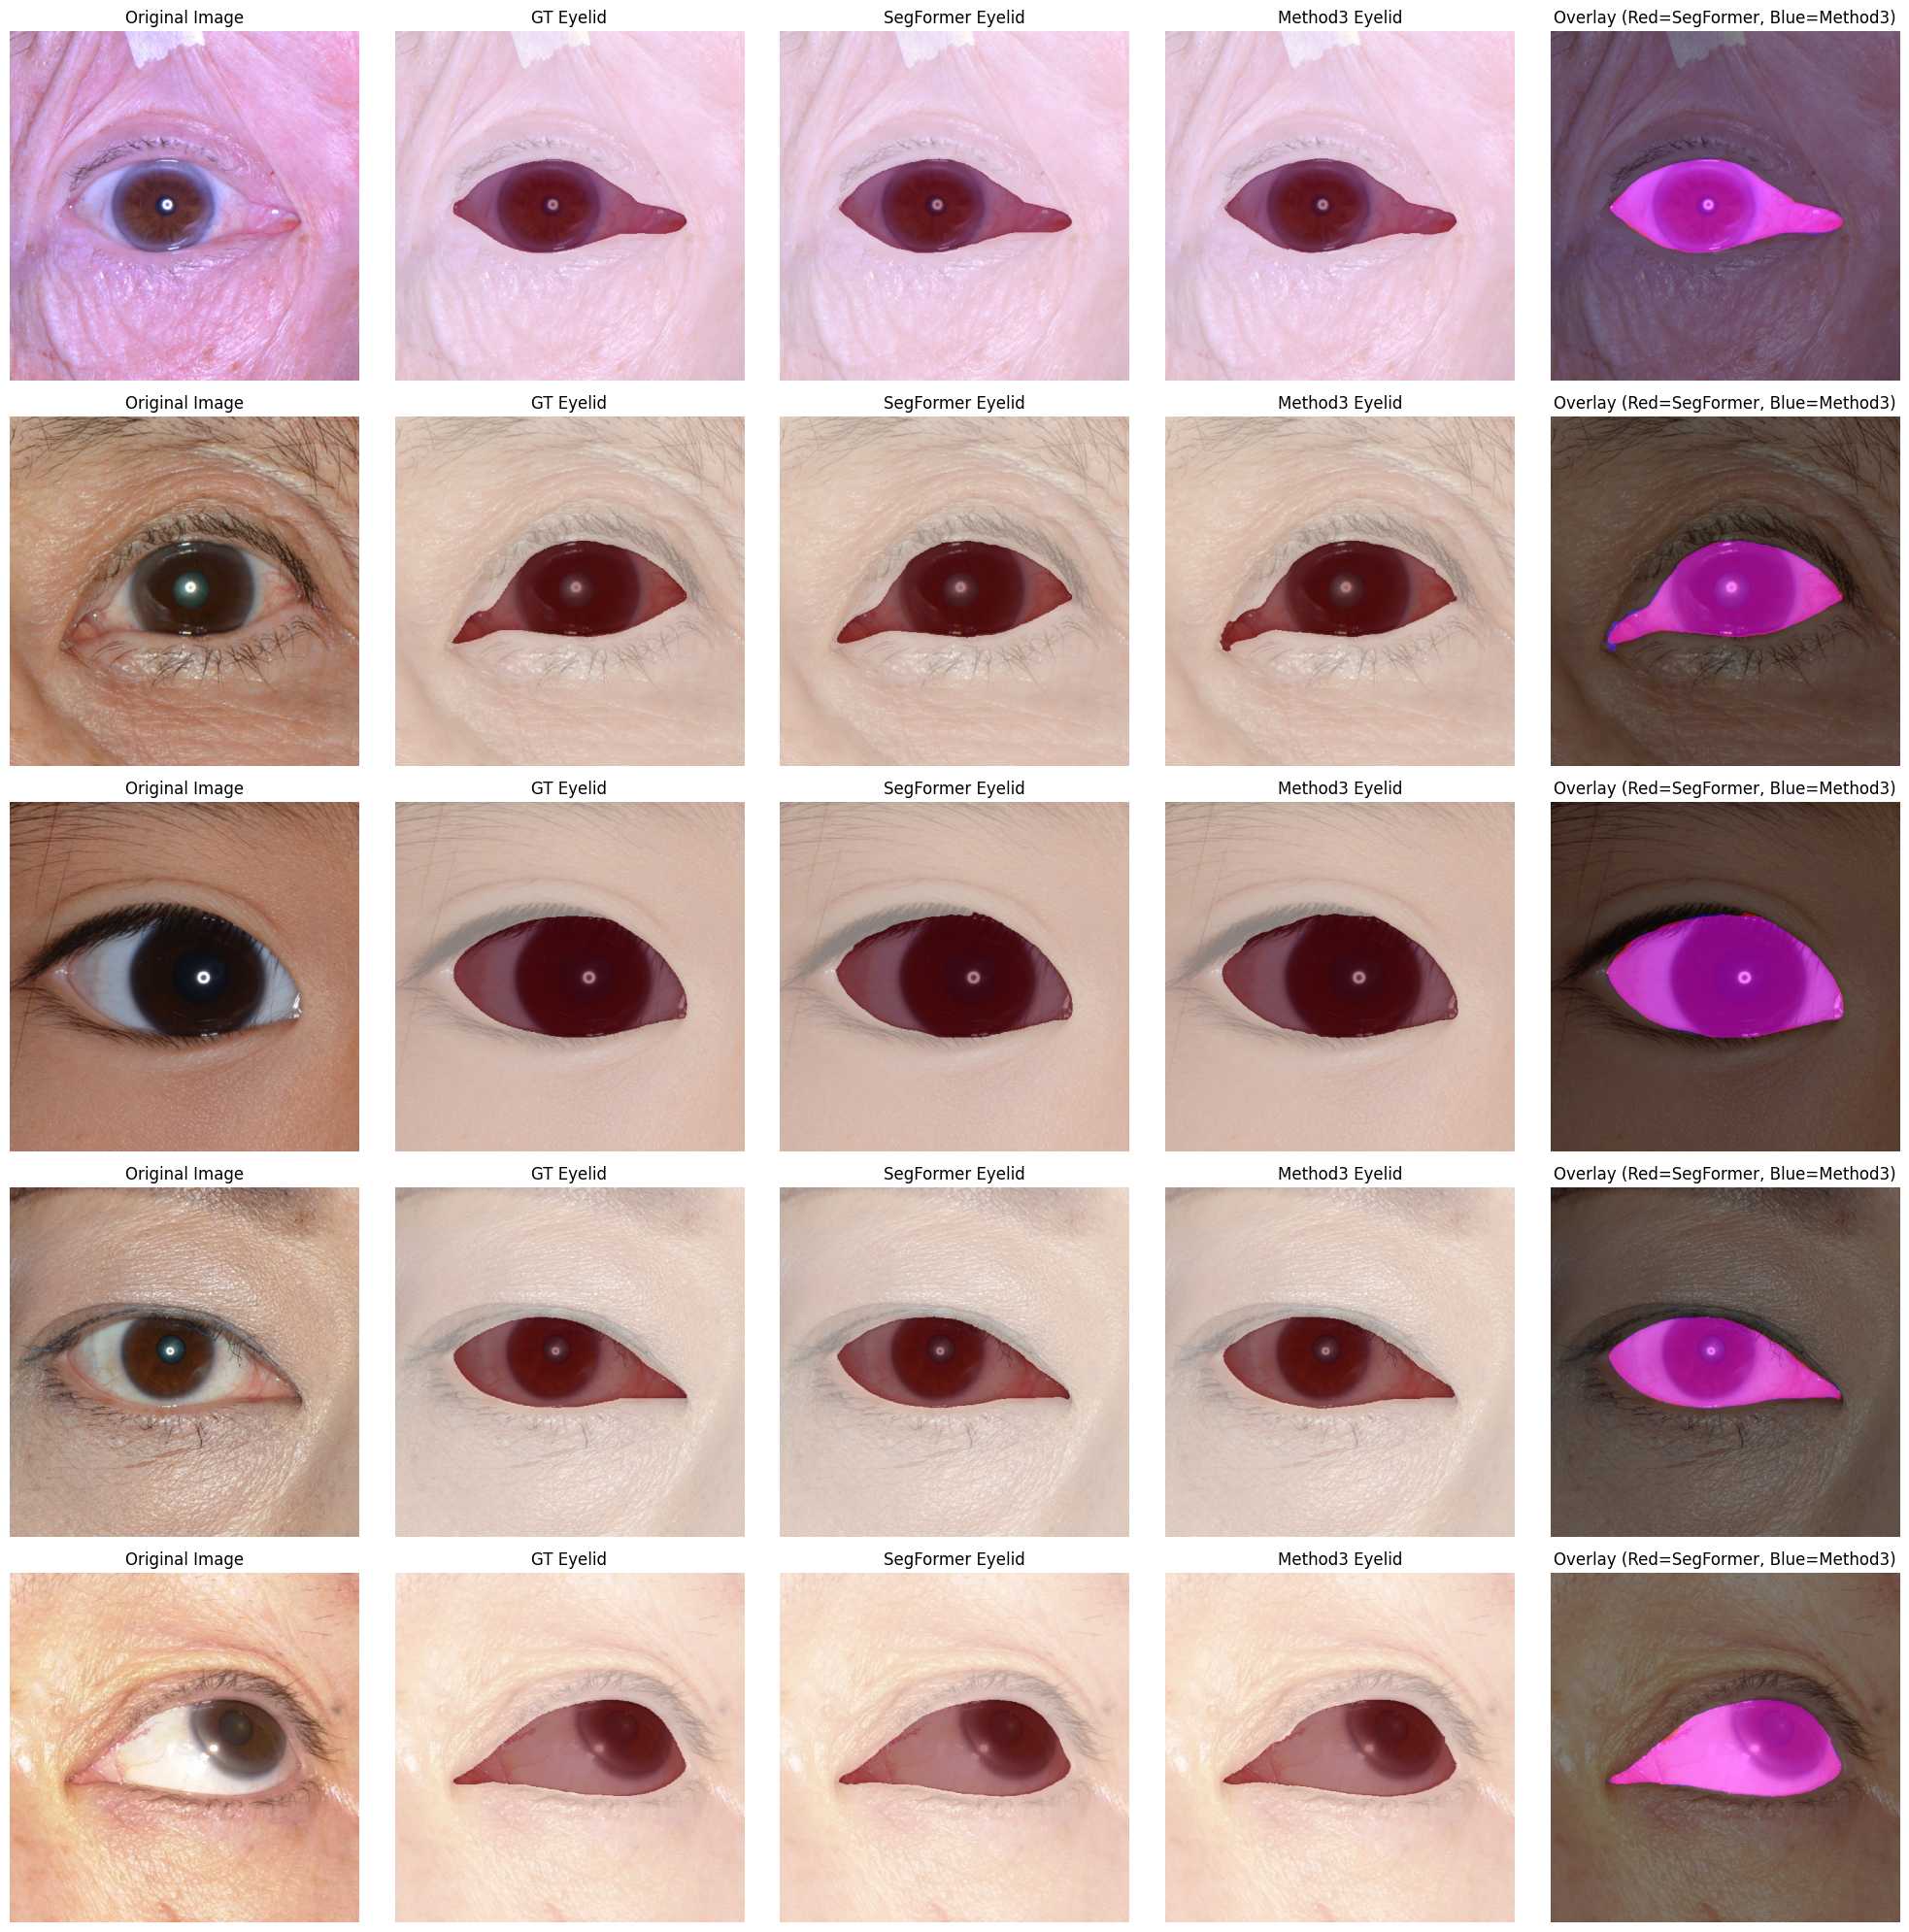

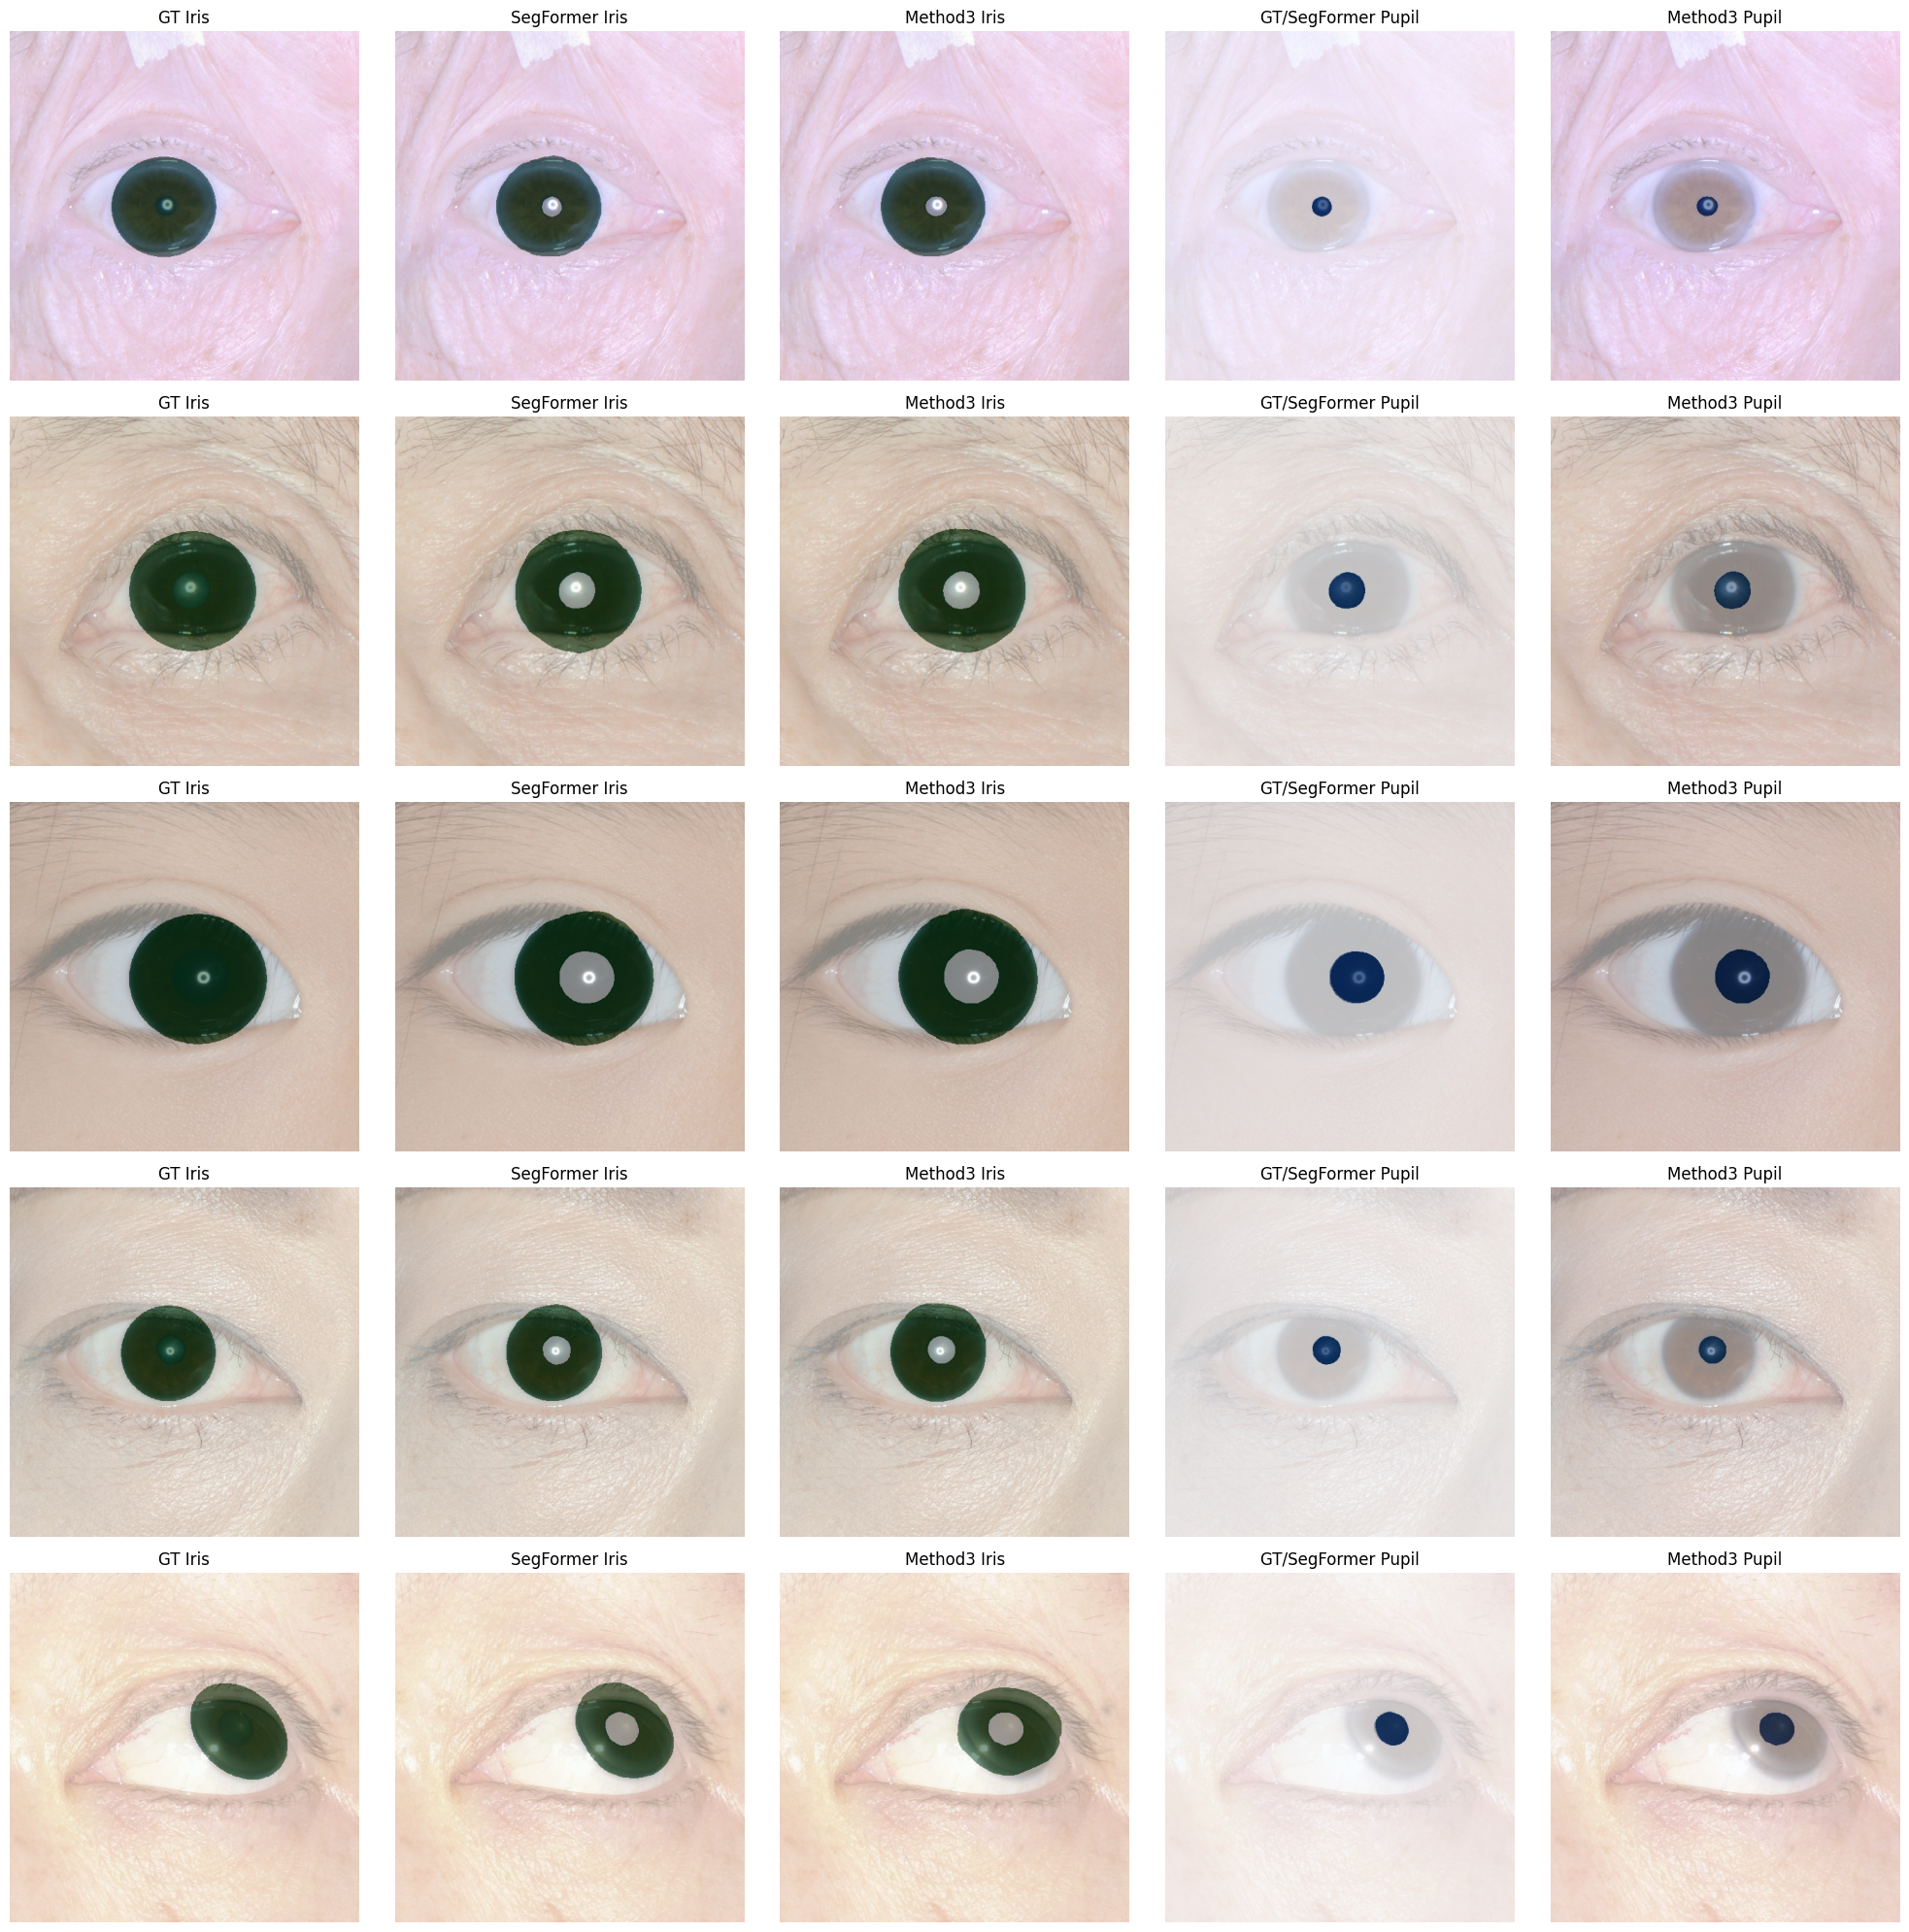

In [18]:
# Method3モデルのロード（U-Net）
# crossvalidation.ipynbで学習したMethod3モデルを使用
METHOD3_MODEL_DIR = Path("model/cv_300ep")

# Method3のモデル定義（crossvalidation.ipynbから）
class UNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        import torchvision
        vgg = torchvision.models.vgg16_bn(weights='DEFAULT')
        self.features = vgg.features

    def forward(self, x):
        feats = {}
        for i, layer in enumerate(self.features):
            x = layer(x)
            if i == 5:  feats['0'] = x
            if i == 12: feats['1'] = x
            if i == 22: feats['2'] = x
            if i == 32: feats['3'] = x
        feats['4'] = x
        return feats

class UNetDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.dec4 = self._blk(512+512, 256)
        self.dec3 = self._blk(256+256, 128)
        self.dec2 = self._blk(128+128, 64)
        self.dec1 = self._blk(64+64,   64)

    def _blk(self, c_in, c_out):
        return nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
            nn.Conv2d(c_out, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU()
        )

    def forward(self, feats):
        x = F.interpolate(feats['4'], size=feats['3'].shape[-2:], mode='bilinear', align_corners=False)
        x = self.dec4(torch.cat([x, feats['3']], dim=1))
        x = F.interpolate(x, size=feats['2'].shape[-2:], mode='bilinear', align_corners=False)
        x = self.dec3(torch.cat([x, feats['2']], dim=1))
        x = F.interpolate(x, size=feats['1'].shape[-2:], mode='bilinear', align_corners=False)
        x = self.dec2(torch.cat([x, feats['1']], dim=1))
        x = F.interpolate(x, size=feats['0'].shape[-2:], mode='bilinear', align_corners=False)
        x = self.dec1(torch.cat([x, feats['0']], dim=1))
        return x

class UNetMethod3(nn.Module):
    """Method3: 6クラス領域セグメンテーション（crossvalidation.ipynb と同一ヘッド構造）"""
    def __init__(self):
        super().__init__()
        self.encoder = UNetEncoder()
        self.decoder = UNetDecoder()
        # checkpoint側のキーが head_seg6.* なので同名・同構造に合わせる
        self.head_seg6 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 6, 1),
        )  # logits

    def forward(self, x):
        feats = self.encoder(x)
        x = self.decoder(feats)
        return {'five_class_seg': self.head_seg6(x)}

# Method3モデルをロード（Fold 0を使用）
method3_model_path = METHOD3_MODEL_DIR / "method3_fold0_best.pth"
if method3_model_path.exists():
    method3_model = UNetMethod3().to(device)
    checkpoint = torch.load(method3_model_path, map_location=device)
    method3_model.load_state_dict(checkpoint['model'])
    print(f"✅ Method3モデルをロードしました: {method3_model_path}")
else:
    print(f"⚠️ Method3モデルが見つかりません: {method3_model_path}")
    print("   crossvalidation.ipynbでMethod3を学習してください。")
    method3_model = None

# SegFormerモデルをロード（最新のFold 0を使用）
segformer_model_path = MODEL_DIR / "segformer_fold0_best.pth"
if segformer_model_path.exists():
    segformer_model = create_segformer_model(num_classes=NUM_CLASSES).to(device)
    checkpoint = torch.load(segformer_model_path, map_location=device)
    segformer_model.load_state_dict(checkpoint['model'])
    print(f"✅ SegFormerモデルをロードしました: {segformer_model_path}")
else:
    print(f"⚠️ SegFormerモデルが見つかりません: {segformer_model_path}")
    print("   先に5-Fold CVを実行してモデルを学習してください。")
    segformer_model = None

# 可視化用データセット（全データから選択）
if segformer_model is not None and method3_model is not None:
    # 検証用データセットを使用（Fold 0の検証セット）
    val_indices = fold_indices['0']['val']
    val_paths = [image_paths[i] for i in val_indices]
    vis_ds = EyeSegmentationDataset(val_paths, LABEL_SEG_DIR, LABEL_OBB_DIR)
    
    print(f"\n📊 可視化を実行します（{len(vis_ds)}サンプルから選択）")
    visualize_comparison(segformer_model, method3_model, vis_ds, num_samples=5, device=device)
else:
    print("\n⚠️ モデルのロードに失敗しました。可視化をスキップします。")
